In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from skbio.diversity.alpha import shannon

In [2]:
###Define Thresholds
rare_species_definition_threshold = 0.1
rare_species_abundance_threshold = 6.5
expressed_gene_reads_threshold = 2000
number_of_samples_expressed_in_threshold = 21

In [3]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_4_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()

metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_4_metadata_merged_luke.csv",
    index_col=0,
)

metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)

unusable_samples = [
    "A2450525897_n01_LICRNA01_A06",
    "A2450525897_n01_LICRNA01_A08",
    "A2450525897_n01_LICRNA01_C11",
    "A2450525897_n01_LICRNA01_D11",
    "A2450525897_n01_LICRNA01_D12",
    "A2449446903_n01_LICRNA02_F01",
    "B2449500127_n01_LICRNA04_A04",
    "B2449500127_n01_LICRNA04_A06",
    "B2449500127_n01_LICRNA04_A07",
]
borderline_unusable = [
    "A2450525897_n01_LICRNA01_F03",
    "A2450525897_n01_LICRNA01_G07",
    "A2449446903_n01_LICRNA02_A04",
    "A2449446903_n01_LICRNA02_H10",
    "B2449500127_n01_LICRNA04_H02",
    "B2449500127_n01_LICRNA04_H11",
]
all_unsable = borderline_unusable + unusable_samples

raw_transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_4_for_norm.csv",
    index_col=0,
)

trimmed_transcriptome = transcriptome.drop(index=all_unsable)
trimmed_metadata = metadata.drop(index=all_unsable)
trimmed_raw_transcriptome = raw_transcriptome.drop(index=all_unsable)
trimmed_metadata = trimmed_metadata.sort_index()
trimmed_transcriptome = trimmed_transcriptome.dropna(how="all", axis=0)
trimmed_transcriptome = trimmed_transcriptome.dropna(how="all", axis=1)

In [4]:
trimmed_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
A2449446903_n01_LICRNA02_A01,0.382839,11.929183,0.0,3.731527,3.602189,0.0,0.0,31.063543,0.0,3.966935,...,17.950907,44.209074,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,6.266498
A2449446903_n01_LICRNA02_A02,0.000000,5.826682,0.0,1.501594,3.439569,0.0,0.0,22.712417,0.0,18.186693,...,1.986484,9.688606,0.0,5.501032,0.0,0.0,0.519342,0.0,0.000000,3.467317
A2449446903_n01_LICRNA02_A03,1.021565,7.683520,0.0,0.301733,2.700528,0.0,0.0,42.431625,0.0,12.937632,...,7.983340,16.384320,0.0,7.983340,0.0,0.0,0.166972,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A05,0.732717,3.149144,0.0,1.947758,3.742586,0.0,0.0,26.541337,0.0,23.861601,...,17.178143,17.005325,0.0,0.000000,0.0,0.0,0.628742,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A06,1.614233,1.238895,0.0,6.130092,4.215597,0.0,0.0,19.379509,0.0,5.006570,...,16.219201,43.599301,0.0,0.000000,0.0,0.0,1.074213,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,0.074367,4.474710,0.0,1.383813,2.059206,0.0,0.0,27.907884,0.0,11.118408,...,3.486989,4.209645,0.0,1.072920,0.0,0.0,0.948096,0.0,0.000000,0.760798
B250508004_n01_LICRNA03_H09,2.232353,6.249002,0.0,1.873955,3.869254,0.0,0.0,40.686812,0.0,7.391606,...,9.640892,4.655562,0.0,5.085306,0.0,0.0,0.360071,0.0,1.758217,4.807925
B250508004_n01_LICRNA03_H10,0.000000,0.000000,0.0,0.000000,2.953706,0.0,0.0,36.084398,0.0,0.000000,...,0.000000,4.975538,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000
B250508004_n01_LICRNA03_H11,0.678594,7.655887,0.0,0.901942,4.195848,0.0,0.0,54.077818,0.0,0.334834,...,0.000000,2.304762,0.0,0.000000,0.0,0.0,0.166371,0.0,0.000000,0.694222


In [5]:
microbiome_abundance = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_16S_rab.csv"
)
long_term_microbiome = microbiome_abundance.merge(
    metadata[["sampID", "Experiment Type"]], left_on="plantID", right_on="sampID"
)
long_term_microbiome

,Sample,sample.type,timepoint,date,time,platename,daysincestart,plantID,Kingdom,Phylum,Class,Order,Family,Genus,Species,AbundR100,sampID,Experiment Type
0,LIC522,plant,c1_t11,2/11/24,12:00,LICCIRC_02,102,LIC522,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales_A_650611,Pseudomonadaceae,Pseudomonas_E_647464,Pseudomonas_E_647464 viridiflava,79.1,LIC522,Circadian Experiment 1
1,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,66.1,LIC063,Long Term
2,LIC159,plant,t14,1/23/24,8:00,LIC_02,83,LIC159,d__Bacteria,Cyanobacteriota,Cyanobacteriia,Cyanobacteriales,Coleofasciculaceae,Caldora,Caldora sp010672925,60.5,LIC159,Long Term
3,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,101,LIC452,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Burkholderiaceae_A_595421,Massilia_574544,Massilia atriviolacea,59.8,LIC452,Circadian Experiment 1
4,LIC306,plant,t26,3/8/24,8:00,LIC_04,128,LIC306,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,57.2,LIC306,Long Term
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12281,LIC122,plant,t11,12/15/23,8:00,LIC_02,44,LIC122,d__Bacteria,Actinomycetota,Actinomycetes,Propionibacteriales,Nocardioidaceae,Nocardioides_A_392796,Nocardioides_A_392796 hankookensis,0.5,LIC122,Long Term
12282,LIC028,plant,t03,11/14/23,8:00,LIC_01,13,LIC028,d__Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Geodermatophilaceae,Modestobacter,Modestobacter muralis,0.5,LIC028,Long Term
12283,LIC631,plant,c2_t05,3/2/24,12:00,LICCIRC_03,122,LIC631,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Caulobacterales,Caulobacteraceae,Brevundimonas,Brevundimonas subvibrioides,0.5,LIC631,Circadian Experiment 2
12284,LIC629,plant,c2_t05,3/2/24,12:00,LICCIRC_03,122,LIC629,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales_505101,Rhizobiaceae,Agrobacterium,Agrobacterium larrymoorei,0.5,LIC629,Circadian Experiment 2


In [6]:
species_abundance_table = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/species_core_results.csv"
)
species_abundance_table

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
0,Kordiimonas sp002401685,372,3.661053,3.30,1.000000,True
1,Sphingomonas_L_486704 sp000786205,372,17.954211,15.90,1.000000,True
2,Rhodoferax_C aquaticus,370,4.407143,3.70,0.994624,True
3,Neorhizobium soli,366,3.855080,2.25,0.983871,True
4,Klenkia sp001424455,363,3.581402,2.70,0.975806,True
...,...,...,...,...,...,...
274,Tardiphaga robiniae,1,0.500000,0.50,0.002688,False
275,Telluria timonae,1,10.800000,10.80,0.002688,False
276,UBA4416 sp002420145,1,0.700000,0.70,0.002688,False
277,Umezawaea tangerina,1,1.100000,1.10,0.002688,False


In [7]:
species_abundance_table["rare"] = False
species_abundance_table.loc[
    species_abundance_table["n_samples_present"] <= 37, "rare"
] = True
species_abundance_table

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core,rare
0,Kordiimonas sp002401685,372,3.661053,3.30,1.000000,True,False
1,Sphingomonas_L_486704 sp000786205,372,17.954211,15.90,1.000000,True,False
2,Rhodoferax_C aquaticus,370,4.407143,3.70,0.994624,True,False
3,Neorhizobium soli,366,3.855080,2.25,0.983871,True,False
4,Klenkia sp001424455,363,3.581402,2.70,0.975806,True,False
...,...,...,...,...,...,...,...
274,Tardiphaga robiniae,1,0.500000,0.50,0.002688,False,True
275,Telluria timonae,1,10.800000,10.80,0.002688,False,True
276,UBA4416 sp002420145,1,0.700000,0.70,0.002688,False,True
277,Umezawaea tangerina,1,1.100000,1.10,0.002688,False,True


In [8]:
list_of_rare_species = species_abundance_table.loc[
    species_abundance_table["rare"] == True, "Species"
].tolist()
list_of_core_species = species_abundance_table.loc[
    species_abundance_table["core"] == True, "Species"
].tolist()
list_of_rare_species

['Bradyrhizobium sp000938255',
 'Noviherbaspirillum_A_568104 psychrotolerans',
 'Brevundimonas huaxiensis',
 'Mycobacterium paragordonae',
 'Aeromicrobium sp001426485',
 'Marmoricola_A_392027 sp001424755',
 'Flavobacterium sangjuense',
 'Herbaspirillum robiniae',
 'Hylemonella sp001432305',
 'Telluria mixta',
 'Undibacterium arcticum',
 'Brevundimonas sp001424025',
 'Herminiimonas arsenicoxydans',
 'Amnibacterium kyonggiense',
 'Patulibacter minatonensis',
 'Aquabacterium_A_592457 parvum',
 'Chioneia frigida',
 'Curtobacterium sp001422205',
 'Kineosporia rhamnosa',
 'Pseudonocardia hierapolitana',
 'Nakamurella panacisegetis',
 'Curvibacter gracilis',
 'Agrobacterium rubi',
 'Nocardioides_A_392796 ginsengisegetis',
 'Pseudoduganella namucuonensis',
 'Pseudomonas_E_647464 rhizosphaerae',
 'Actinoplanes rectilineatus',
 'Microbacterium_A_383321 testaceum_F',
 'Actinoplanes globisporus',
 'Herbaspirillum seropedicae',
 'Methylophilus methylotrophus',
 'Pseudomonas_E_647626 sp900573885',
 

In [9]:
# For each sample, check if it has any rare species or is lacking any core species
rare_species_set = set(list_of_rare_species)
core_species_set = set(list_of_core_species)

# Get species-level summaries for each sample (using sampID from long_term_microbiome)
sample_species = long_term_microbiome.groupby("sampID")["Species"].apply(set)
sample_timepoint = long_term_microbiome.groupby("sampID")["timepoint"].first()
total_species_present = sample_species.apply(len)
core_species_present_count = sample_species.apply(
    lambda species: len(species & core_species_set)
)

# Compute Shannon diversity from each sample's species abundance profile
sample_shannon = (
    long_term_microbiome.loc[:, ["sampID", "Species", "AbundR100"]]
    .assign(
        AbundR100=lambda d: pd.to_numeric(d["AbundR100"], errors="coerce").fillna(0.0)
    )
    .groupby(["sampID", "Species"], sort=False)["AbundR100"]
    .sum()
    .groupby(level=0, sort=False)
    .apply(lambda abundances: shannon(abundances.to_numpy()))
    .rename("shannon_diversity")
)

# Check if sample has any rare species
has_rare_species = sample_species.apply(lambda x: len(x & rare_species_set) > 0)

# Check if sample is lacking any core species (missing at least one core species)
lacking_core_species = sample_species.apply(lambda x: not core_species_set.issubset(x))

# Total relative abundance of rare species per sample (sum of AbundR100 over rare species)
rare_abund_by_sample = (
    long_term_microbiome.loc[
        long_term_microbiome["Species"].isin(rare_species_set),
        ["sampID", "AbundR100"],
    ]
    .assign(
        AbundR100=lambda d: pd.to_numeric(d["AbundR100"], errors="coerce").fillna(
            0.0
        )  ##Junky column that just makes sure that its numeric
    )
    .groupby("sampID", sort=False)["AbundR100"]
    .sum()
    .rename("rare_species_total_abundR100")
)

# Add columns to metadata using the sampID column (not the index)
trimmed_metadata["timepoint"] = trimmed_metadata["sampID"].map(sample_timepoint)
trimmed_metadata["shannon_diversity"] = (
    trimmed_metadata["sampID"].map(sample_shannon).fillna(0.0)
)
trimmed_metadata["total_species_present"] = trimmed_metadata["sampID"].map(
    lambda sample_id: int(total_species_present.get(sample_id, 0))
)
trimmed_metadata["n_core_species_present"] = trimmed_metadata["sampID"].map(
    lambda sample_id: int(core_species_present_count.get(sample_id, 0))
)
trimmed_metadata["has_rare_species"] = trimmed_metadata["sampID"].map(
    lambda sample_id: bool(has_rare_species.get(sample_id, False))
)
trimmed_metadata["lacking_core_species"] = trimmed_metadata["sampID"].map(
    lambda sample_id: bool(lacking_core_species.get(sample_id, True))
)
trimmed_metadata["rare_species_total_abundR100"] = (
    trimmed_metadata["sampID"].map(rare_abund_by_sample).fillna(0.0)
)

trimmed_metadata[
    [
        "sampID",
        "timepoint",
        "shannon_diversity",
        "total_species_present",
        "n_core_species_present",
        "has_rare_species",
        "lacking_core_species",
        "rare_species_total_abundR100",
    ]
]

,sampID,timepoint,shannon_diversity,total_species_present,n_core_species_present,has_rare_species,lacking_core_species,rare_species_total_abundR100
filename,,,,,,,,
A2449446903_n01_LICRNA02_A01,LIC157,t14,3.566500,54,10,True,False,13.5
A2449446903_n01_LICRNA02_A02,LIC169,t15,2.268220,21,9,True,True,0.7
A2449446903_n01_LICRNA02_A03,LIC193,t17,2.409302,28,10,True,False,1.7
A2449446903_n01_LICRNA02_A05,LIC217,t19,2.914743,35,10,True,False,1.0
A2449446903_n01_LICRNA02_A06,LIC229,t20,2.849462,37,9,True,True,5.0
...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,LIC428,c1_t04,1.536957,17,9,False,True,0.0
B250508004_n01_LICRNA03_H09,LIC440,c1_t05,2.330638,22,10,False,False,0.0
B250508004_n01_LICRNA03_H10,LIC452,c1_t06,1.516584,18,8,True,True,1.0


In [10]:
trimmed_metadata["Ln(number of species)"] = np.log(
    trimmed_metadata["total_species_present"]
)
trimmed_metadata["Pielou Evenness"] = (
    trimmed_metadata["shannon_diversity"] / trimmed_metadata["Ln(number of species)"]
)
trimmed_metadata

/Users/michael/miniconda3/envs/Luke_terrace/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,...,daysincestart,Date and Time,shannon_diversity,total_species_present,n_core_species_present,has_rare_species,lacking_core_species,rare_species_total_abundR100,Ln(number of species),Pielou Evenness
filename,,,,,,,,,,,,,,,,,,,,,
A2449446903_n01_LICRNA02_A01,A01,LIC157,plant,t14,1/23/24,8:00,LIC_02,LICRNA_02,758284.0,82176.0,...,83,2024-01-23 08:00:00,3.566500,54,10,True,False,13.5,3.988984,0.894087
A2449446903_n01_LICRNA02_A02,A02,LIC169,plant,t15,1/27/24,8:00,LIC_02,LICRNA_02,3071877.0,353549.0,...,87,2024-01-27 08:00:00,2.268220,21,9,True,True,0.7,3.044522,0.745017
A2449446903_n01_LICRNA02_A03,A03,LIC193,plant,t17,2/2/24,8:00,LIC_03,LICRNA_02,1213638.0,158864.0,...,93,2024-02-02 08:00:00,2.409302,28,10,True,False,1.7,3.332205,0.723035
A2449446903_n01_LICRNA02_A05,A05,LIC217,plant,t19,2/9/24,8:00,LIC_03,LICRNA_02,1303436.0,90929.0,...,100,2024-02-09 08:00:00,2.914743,35,10,True,False,1.0,3.555348,0.819819
A2449446903_n01_LICRNA02_A06,A06,LIC229,plant,t20,2/16/24,8:00,LIC_03,LICRNA_02,1591231.0,141665.0,...,107,2024-02-16 08:00:00,2.849462,37,9,True,True,5.0,3.610918,0.789124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,H08,LIC428,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_03,2552177.0,438552.0,...,101,2024-02-10 08:00:00,1.536957,17,9,False,True,0.0,2.833213,0.542478
B250508004_n01_LICRNA03_H09,H09,LIC440,plant,c1_t05,2/10/24,12:00,LICCIRC_01,LICRNA_03,4228242.0,493699.0,...,101,2024-02-10 12:00:00,2.330638,22,10,False,False,0.0,3.091042,0.753997
B250508004_n01_LICRNA03_H10,H10,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,LICRNA_03,365095.0,39090.0,...,101,2024-02-10 16:00:00,1.516584,18,8,True,True,1.0,2.890372,0.524702


In [11]:
pca_info = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/first4plates_metadata_with_pca_info.csv",
    index_col=0,
)
pca_info

,plate.pos,arb.sort,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,...,Ambiguous Unstranded,Ambiguous Forward,plate_row,plate_col,Total Reads,Unmapped Over Mapped,Experiment Type,Sample Month,PCA 1,PCA 2
filename,,,,,,,,,,,,,,,,,,,,,
A2449446903_n01_LICRNA02_A01,A01,1,LIC157,plant,t14,1/23/24,8:00,LIC_02,LICRNA_02,758284.0,...,103821.0,14939.0,A,1,1246970.0,0.608101,Long Term,January,-18067.168411,-7126.008382
A2449446903_n01_LICRNA02_A02,A02,9,LIC169,plant,t15,1/27/24,8:00,LIC_02,LICRNA_02,3071877.0,...,398670.0,57289.0,A,2,4985602.0,0.616150,Long Term,January,43315.114596,1266.803344
A2449446903_n01_LICRNA02_A03,A03,17,LIC193,plant,t17,2/2/24,8:00,LIC_03,LICRNA_02,1213638.0,...,207527.0,27420.0,A,3,2465662.0,0.492216,Long Term,February,60647.401072,4256.940781
A2449446903_n01_LICRNA02_A04,A04,25,LIC205,plant,t18,2/6/24,8:00,LIC_03,LICRNA_02,306394.0,...,46310.0,6783.0,A,4,564891.0,0.542395,Long Term,February,5814.322046,-11569.802544
A2449446903_n01_LICRNA02_A05,A05,33,LIC217,plant,t19,2/9/24,8:00,LIC_03,LICRNA_02,1303436.0,...,125368.0,19337.0,A,5,1515395.0,0.860130,Long Term,February,-37769.908468,-58202.606514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,H08,64,LIC428,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_03,2552177.0,...,460177.0,61087.0,H,8,5245242.0,0.486570,Circadian Experiment 1,February,44343.641848,47194.468885
B250508004_n01_LICRNA03_H09,H09,72,LIC440,plant,c1_t05,2/10/24,12:00,LICCIRC_01,LICRNA_03,4228242.0,...,645602.0,93443.0,H,9,7715482.0,0.548020,Circadian Experiment 1,February,63473.479410,-35363.572231
B250508004_n01_LICRNA03_H10,H10,80,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,LICRNA_03,365095.0,...,55347.0,7763.0,H,10,643786.0,0.567106,Circadian Experiment 1,February,28251.052177,-32947.171001


In [12]:
trimmed_metadata = trimmed_metadata.merge(
    pca_info[["PCA 1", "PCA 2"]], left_index=True, right_index=True, how="left"
)

In [13]:
trimmed_metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,...,shannon_diversity,total_species_present,n_core_species_present,has_rare_species,lacking_core_species,rare_species_total_abundR100,Ln(number of species),Pielou Evenness,PCA 1,PCA 2
filename,,,,,,,,,,,,,,,,,,,,,
A2449446903_n01_LICRNA02_A01,A01,LIC157,plant,t14,1/23/24,8:00,LIC_02,LICRNA_02,758284.0,82176.0,...,3.566500,54,10,True,False,13.5,3.988984,0.894087,-18067.168411,-7126.008382
A2449446903_n01_LICRNA02_A02,A02,LIC169,plant,t15,1/27/24,8:00,LIC_02,LICRNA_02,3071877.0,353549.0,...,2.268220,21,9,True,True,0.7,3.044522,0.745017,43315.114596,1266.803344
A2449446903_n01_LICRNA02_A03,A03,LIC193,plant,t17,2/2/24,8:00,LIC_03,LICRNA_02,1213638.0,158864.0,...,2.409302,28,10,True,False,1.7,3.332205,0.723035,60647.401072,4256.940781
A2449446903_n01_LICRNA02_A05,A05,LIC217,plant,t19,2/9/24,8:00,LIC_03,LICRNA_02,1303436.0,90929.0,...,2.914743,35,10,True,False,1.0,3.555348,0.819819,-37769.908468,-58202.606514
A2449446903_n01_LICRNA02_A06,A06,LIC229,plant,t20,2/16/24,8:00,LIC_03,LICRNA_02,1591231.0,141665.0,...,2.849462,37,9,True,True,5.0,3.610918,0.789124,-26857.047389,22158.437296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,H08,LIC428,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_03,2552177.0,438552.0,...,1.536957,17,9,False,True,0.0,2.833213,0.542478,44343.641848,47194.468885
B250508004_n01_LICRNA03_H09,H09,LIC440,plant,c1_t05,2/10/24,12:00,LICCIRC_01,LICRNA_03,4228242.0,493699.0,...,2.330638,22,10,False,False,0.0,3.091042,0.753997,63473.479410,-35363.572231
B250508004_n01_LICRNA03_H10,H10,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,LICRNA_03,365095.0,39090.0,...,1.516584,18,8,True,True,1.0,2.890372,0.524702,28251.052177,-32947.171001


In [16]:
trimmed_metadata["Dysbiosis Status"] = "Not Dysbiotic"
trimmed_metadata["Dysbiosis Status"].loc[
    trimmed_metadata["rare_species_total_abundR100"] > rare_species_abundance_threshold
] = "Dysbiotic"

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_14805/255710534.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  trimmed_metadata["Dysbiosis Status"].loc[
/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_14805/2557105

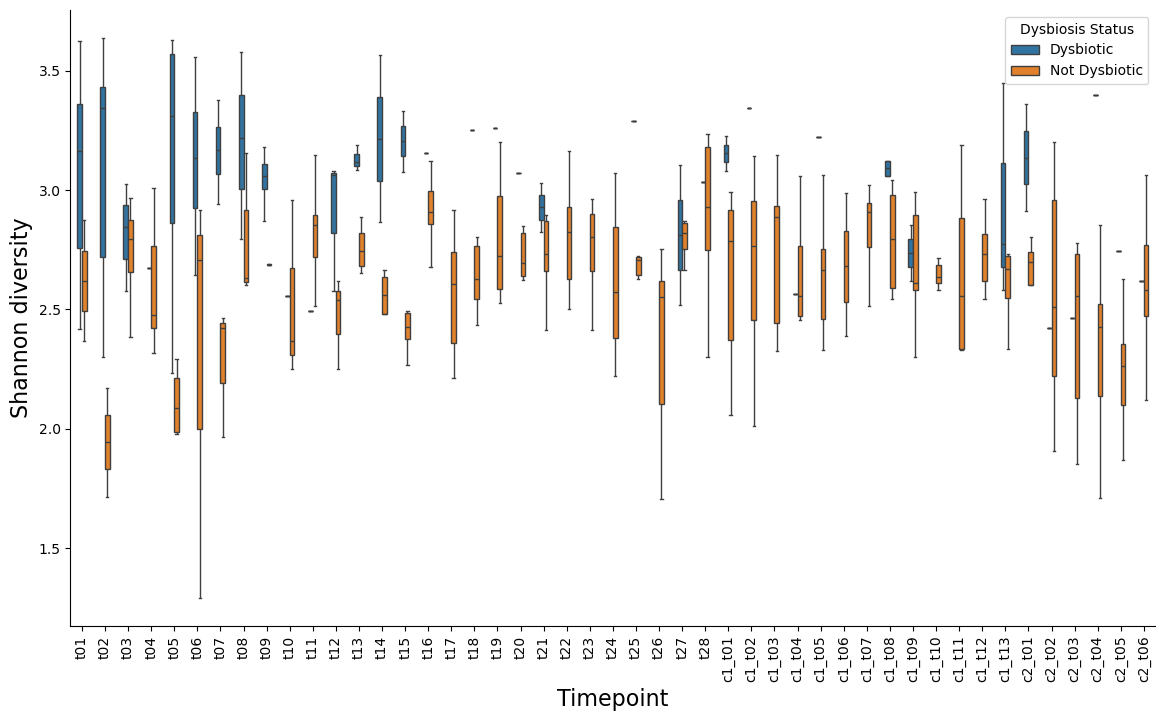

In [18]:
timepoint_plot_data = trimmed_metadata.dropna(
    subset=["timepoint", "shannon_diversity", "Dysbiosis Status", "Pielou Evenness"]
).copy()
timepoint_order = sorted(
    timepoint_plot_data["timepoint"].unique(),
    key=lambda value: int("".join(filter(str.isdigit, str(value))) or -1),
)

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor("white")
sns.boxplot(
    data=timepoint_plot_data,
    x="timepoint",
    y="shannon_diversity",
    hue="Dysbiosis Status",
    order=timepoint_order,
    dodge=True,
    ax=ax,
    showfliers=False,
    width=0.4,
)
plt.xlabel("Timepoint", fontsize=16)
plt.ylabel("Shannon diversity", fontsize=16)
plt.xticks(rotation=90)
ax.legend(title="Dysbiosis Status", loc="upper right")
sns.despine()

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_14805/209640268.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Dysbiosis Status", loc="upper right")


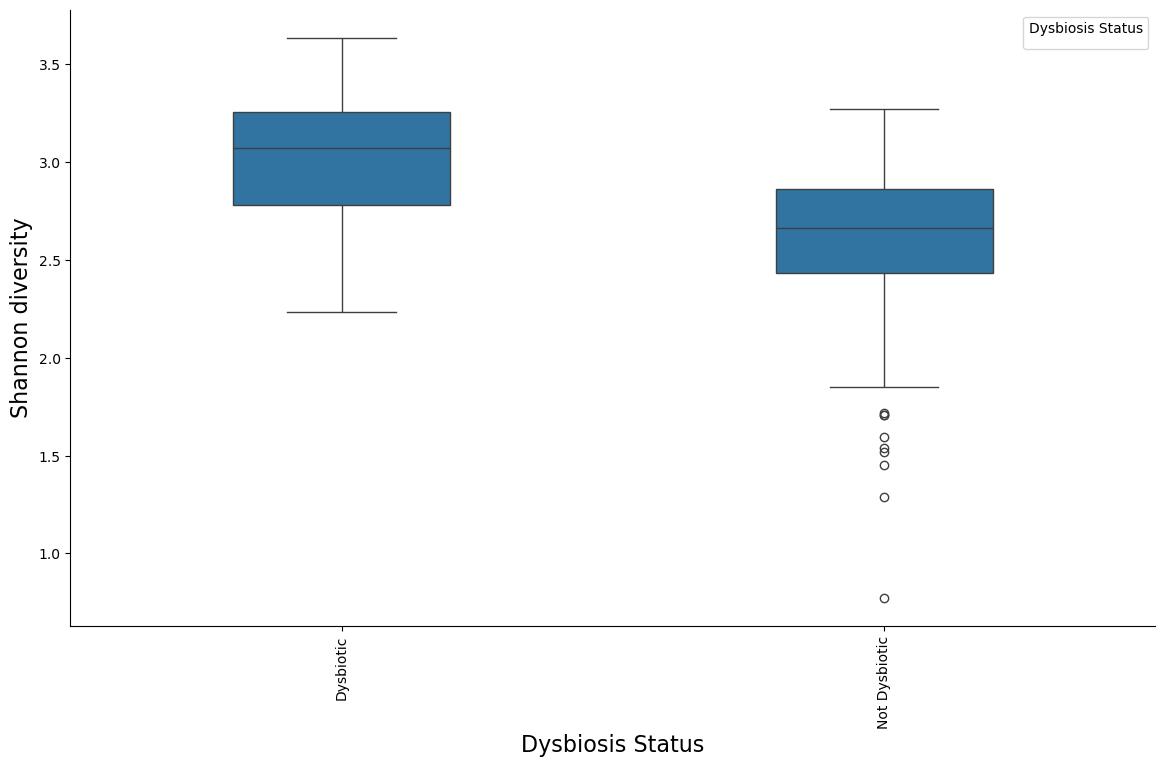

In [23]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor("white")
sns.boxplot(
    data=timepoint_plot_data,
    x="Dysbiosis Status",
    y="shannon_diversity",
    dodge=True,
    ax=ax,
    showfliers=True,
    width=0.4,
)
plt.xlabel("Dysbiosis Status", fontsize=16)
plt.ylabel("Shannon diversity", fontsize=16)
plt.xticks(rotation=90)
ax.legend(title="Dysbiosis Status", loc="upper right")
sns.despine()

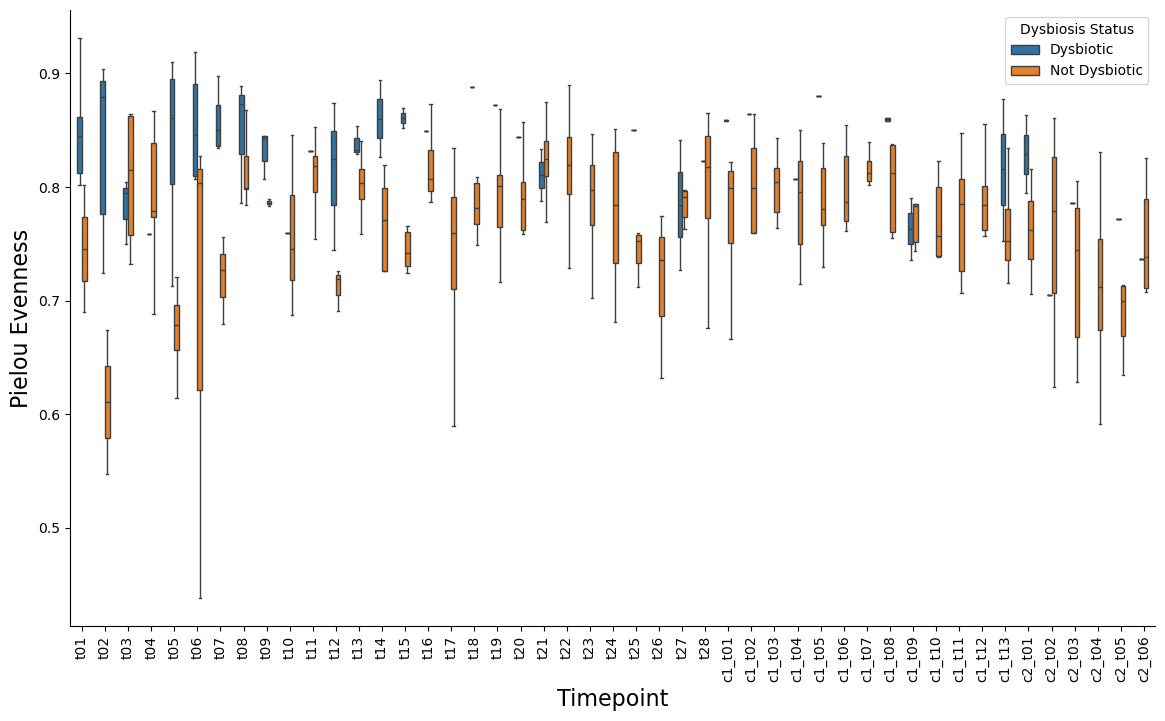

In [24]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor("white")
sns.boxplot(
    data=timepoint_plot_data,
    x="timepoint",
    y="Pielou Evenness",
    hue="Dysbiosis Status",
    order=timepoint_order,
    dodge=True,
    ax=ax,
    showfliers=False,
    width=0.4,
)
plt.xlabel("Timepoint", fontsize=16)
plt.ylabel("Pielou Evenness", fontsize=16)
plt.xticks(rotation=90)
ax.legend(title="Dysbiosis Status", loc="upper right")
sns.despine()

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_14805/3860432672.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Dysbiosis Status", loc="upper right")


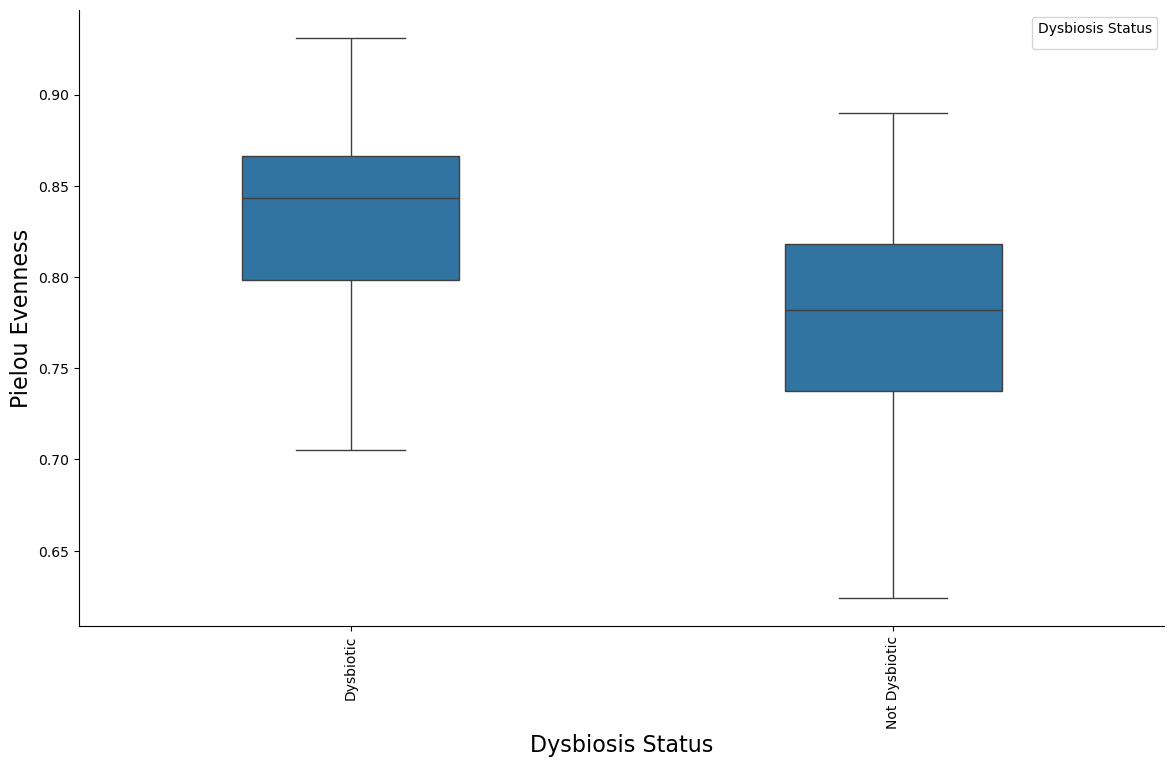

In [21]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor("white")
sns.boxplot(
    data=timepoint_plot_data,
    x="Dysbiosis Status",
    y="Pielou Evenness",
    dodge=True,
    ax=ax,
    showfliers=False,
    width=0.4,
)
plt.xlabel("Dysbiosis Status", fontsize=16)
plt.ylabel("Pielou Evenness", fontsize=16)
plt.xticks(rotation=90)
ax.legend(title="Dysbiosis Status", loc="upper right")
sns.despine()

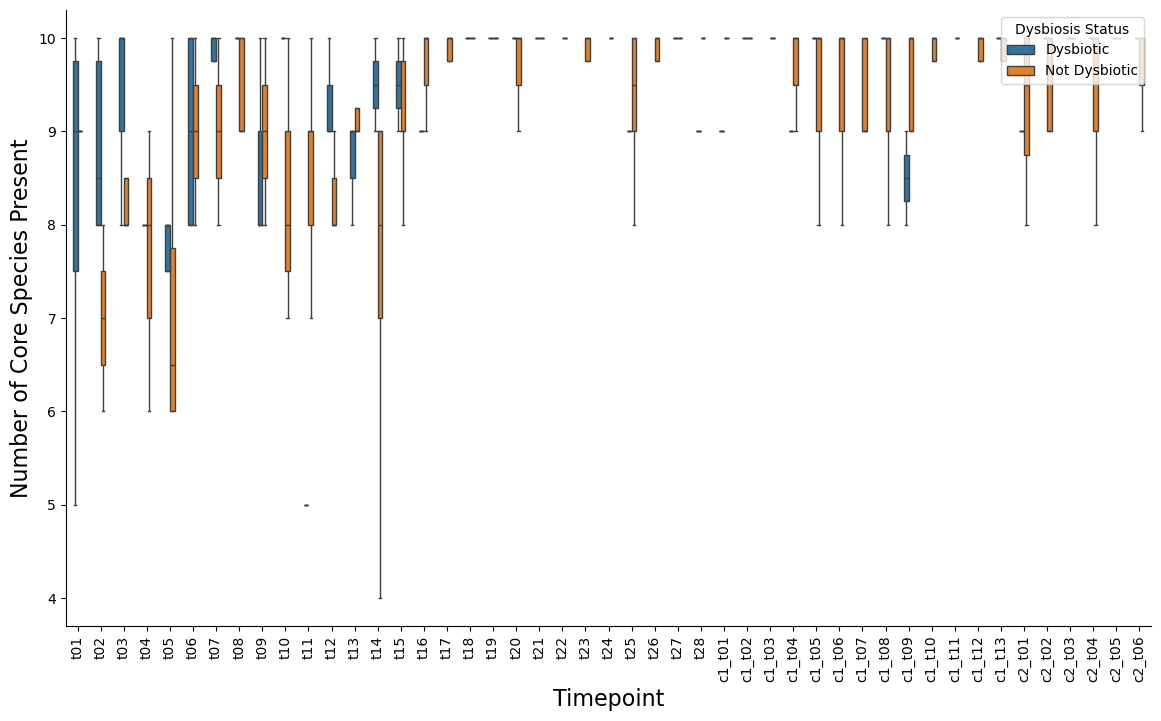

In [46]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor("white")
sns.boxplot(
    data=timepoint_plot_data,
    x="timepoint",
    y="n_core_species_present",
    hue="Dysbiosis Status",
    order=timepoint_order,
    dodge=True,
    ax=ax,
    showfliers=False,
    width=0.4,
)
plt.xlabel("Timepoint", fontsize=16)
plt.ylabel("Number of Core Species Present", fontsize=16)
plt.xticks(rotation=90)
ax.legend(title="Dysbiosis Status", loc="upper right")
sns.despine()

In [48]:
timepoint_plot_data

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,...,Date and Time,has_rare_species,lacking_core_species,rare_species_total_abundR100,shannon_diversity,n_core_species_present,PCA 1,PCA 2,Dysbiosis Status,dysbiosis_flag
filename,,,,,,,,,,,,,,,,,,,,,
A2449446903_n01_LICRNA02_A01,A01,LIC157,plant,t14,1/23/24,8:00,LIC_02,LICRNA_02,758284.0,82176.0,...,2024-01-23 08:00:00,True,False,13.5,3.566500,10,-18067.168411,-7126.008382,Dysbiotic,True
A2449446903_n01_LICRNA02_A02,A02,LIC169,plant,t15,1/27/24,8:00,LIC_02,LICRNA_02,3071877.0,353549.0,...,2024-01-27 08:00:00,True,True,0.7,2.268220,9,43315.114596,1266.803344,Not Dysbiotic,False
A2449446903_n01_LICRNA02_A03,A03,LIC193,plant,t17,2/2/24,8:00,LIC_03,LICRNA_02,1213638.0,158864.0,...,2024-02-02 08:00:00,True,False,1.7,2.409302,10,60647.401072,4256.940781,Not Dysbiotic,False
A2449446903_n01_LICRNA02_A05,A05,LIC217,plant,t19,2/9/24,8:00,LIC_03,LICRNA_02,1303436.0,90929.0,...,2024-02-09 08:00:00,True,False,1.0,2.914743,10,-37769.908468,-58202.606514,Not Dysbiotic,False
A2449446903_n01_LICRNA02_A06,A06,LIC229,plant,t20,2/16/24,8:00,LIC_03,LICRNA_02,1591231.0,141665.0,...,2024-02-16 08:00:00,True,True,5.0,2.849462,9,-26857.047389,22158.437296,Not Dysbiotic,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H08,H08,LIC428,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_03,2552177.0,438552.0,...,2024-02-10 08:00:00,False,True,0.0,1.536957,9,44343.641848,47194.468885,Not Dysbiotic,False
B250508004_n01_LICRNA03_H09,H09,LIC440,plant,c1_t05,2/10/24,12:00,LICCIRC_01,LICRNA_03,4228242.0,493699.0,...,2024-02-10 12:00:00,False,False,0.0,2.330638,10,63473.479410,-35363.572231,Not Dysbiotic,False
B250508004_n01_LICRNA03_H10,H10,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,LICRNA_03,365095.0,39090.0,...,2024-02-10 16:00:00,True,True,1.0,1.516584,8,28251.052177,-32947.171001,Not Dysbiotic,False


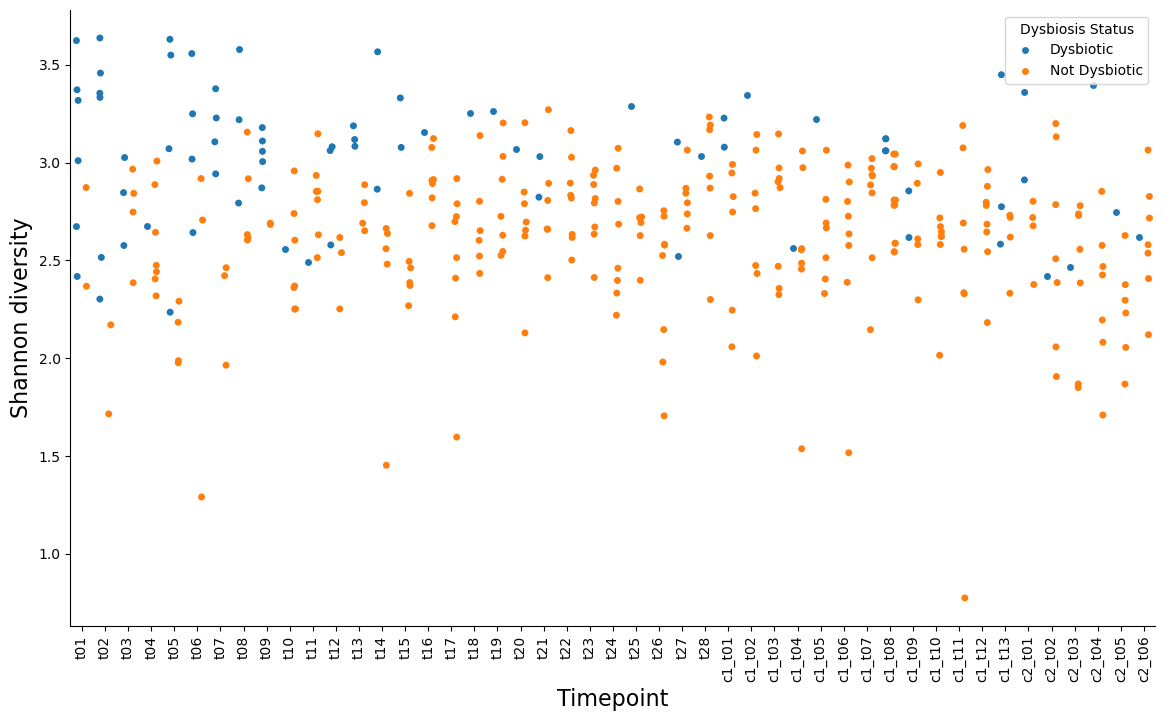

In [37]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor("white")
sns.stripplot(
    data=timepoint_plot_data,
    x="timepoint",
    y="shannon_diversity",
    hue="Dysbiosis Status",
    order=timepoint_order,
    dodge=True,
)
plt.xlabel("Timepoint", fontsize=16)
plt.ylabel("Shannon diversity", fontsize=16)
plt.xticks(rotation=90)
ax.legend(title="Dysbiosis Status", loc="upper right")
sns.despine()

(array([-150000., -100000.,  -50000.,       0.,   50000.,  100000.,
         150000.]),
 [Text(0, -150000.0, '−150000'),
  Text(0, -100000.0, '−100000'),
  Text(0, -50000.0, '−50000'),
  Text(0, 0.0, '0'),
  Text(0, 50000.0, '50000'),
  Text(0, 100000.0, '100000'),
  Text(0, 150000.0, '150000')])

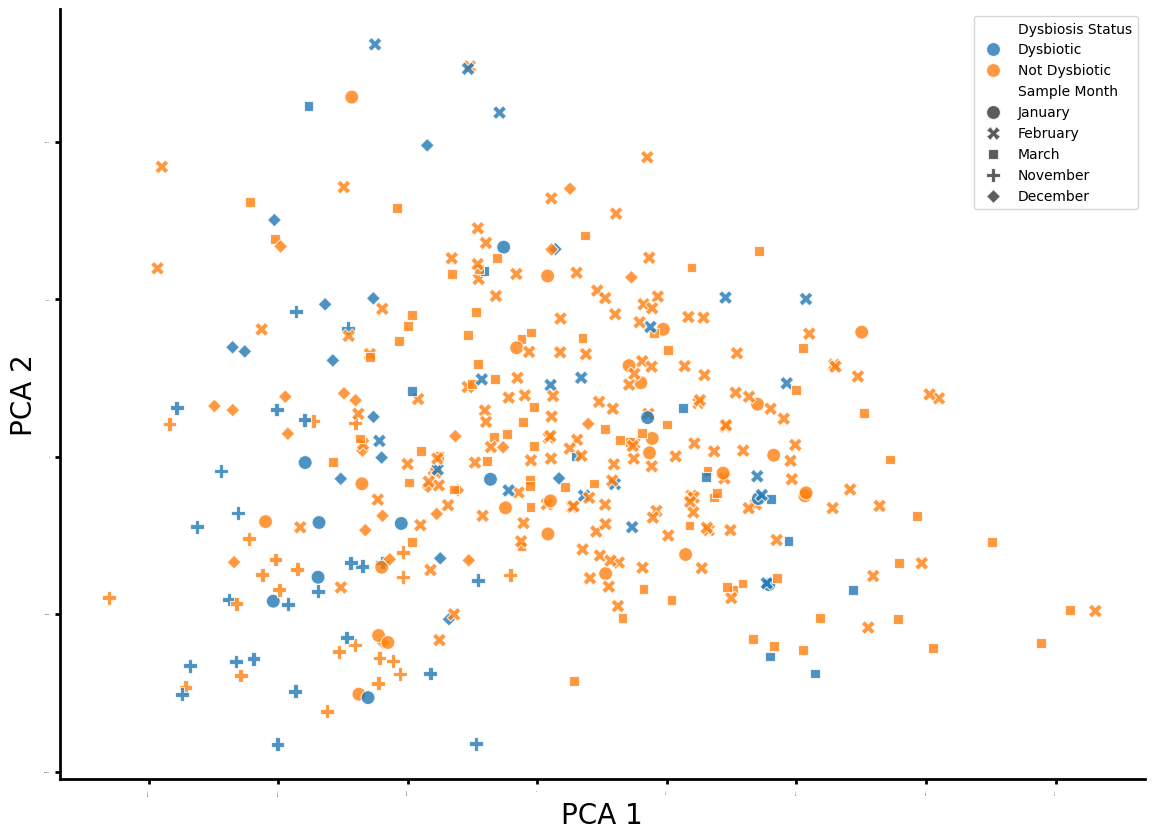

In [23]:
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    data=trimmed_metadata,
    x="PCA 1",
    y="PCA 2",
    hue="Dysbiosis Status",
    style="Sample Month",
    s=100,
    alpha=0.8,
)
plt.xlabel("PCA 1", fontsize=20)
plt.ylabel("PCA 2", fontsize=20)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

# plt.ylim(0,10)

<Axes: xlabel='rare_species_total_abundR100', ylabel='Count'>

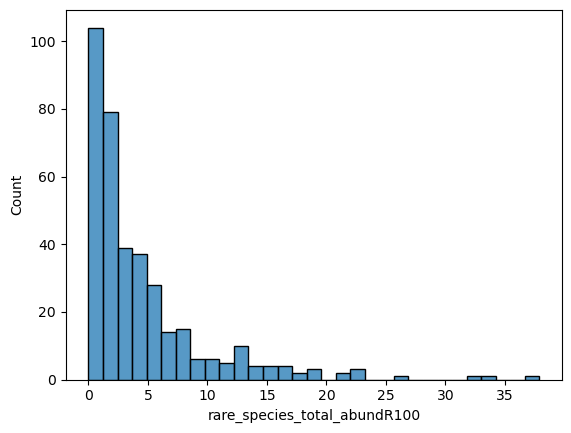

In [12]:
sns.histplot(trimmed_metadata["rare_species_total_abundR100"])